In [1]:
import pandas as pd
import numpy as np

## Create or load a dataframe

### First way: a dictionary

In [2]:
data = pd.DataFrame({'A': [1,2,3], 'B': ["Name", 'Cousin', 'Sister']})

In [3]:
data

,A,B
0,1,Name
1,2,Cousin
2,3,Sister


### Second way: a list

In [4]:
data = pd.DataFrame(np.random.normal(0, 1, size=(10,3)))

In [5]:
data

,0,1,2
0,-0.509613,-1.396733,0.081849
1,0.318570,1.488384,-0.158094
2,0.567976,1.331010,-0.693530
3,-0.663155,1.566730,-0.926987
4,-2.895475,-0.137707,-1.729290
5,3.243980,0.249224,0.728301
6,-2.049527,-0.750463,-0.476279
7,0.736819,-0.681694,-0.897994
8,-0.559425,1.076611,-0.830710
9,-0.429854,0.913079,0.639176


There are no columns names! We can set them....

In [6]:
data.columns = ['First Column', 'Column 1', 'A']

In [7]:
data

,First Column,Column 1,A
0,-0.509613,-1.396733,0.081849
1,0.318570,1.488384,-0.158094
2,0.567976,1.331010,-0.693530
3,-0.663155,1.566730,-0.926987
4,-2.895475,-0.137707,-1.729290
5,3.243980,0.249224,0.728301
6,-2.049527,-0.750463,-0.476279
7,0.736819,-0.681694,-0.897994
8,-0.559425,1.076611,-0.830710
9,-0.429854,0.913079,0.639176


## Exercise 1

Create a pandas dataframe having 4 columns and 1000 rows, where:

- first column is a year of birth column, where year are integers from 1950 to 2000, distribution being uniform
- second column is a female column, where gender can be either 1 or 0, distribution should be binomial with p=0.55
- third column is a height column, where height is normal of mean 175 and standard deviation of 7 centimetres for M
- fourth column is a price column, price being a two digit number going from 10 to 100. This should be a Poisson distribution with lambda=10.

Use numpy functions to compute the random distributions.

In [8]:
df = pd.DataFrame()
df['Birth'] = np.random.randint (low=1950, high=2001, size=1000)
df['Female'] = np.random.binomial(n=1000, p=0.55)
df['Height'] = np.random.normal(loc=175, scale=7, size=1000)
df['Price'] = np.random.poisson(lam=10, size=1000)

### Load from an existing dataset (for example a csv)

In [10]:
data = pd.read_csv('titanic.csv')

In [11]:
data.head()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


We can use the describe function to have some statistics summary on each column (except for the Name one)

In [12]:
data.describe()

,Survived,Pclass,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
count,887.000000,887.000000,887.000000,887.000000,887.000000,887.00000
mean,0.385569,2.305524,29.471443,0.525366,0.383315,32.30542
std,0.487004,0.836662,14.121908,1.104669,0.807466,49.78204
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.00000
25%,0.000000,2.000000,20.250000,0.000000,0.000000,7.92500
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.45420
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.13750
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.32920


<Axes: >

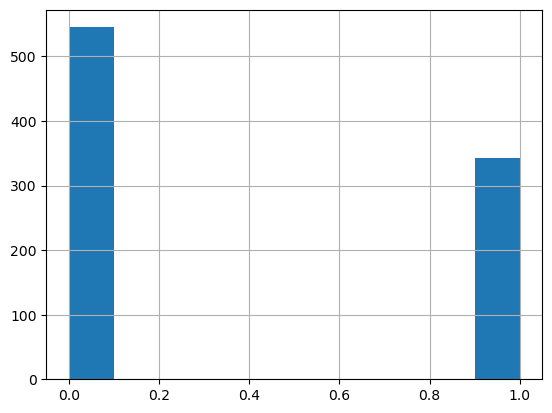

In [13]:
data['Survived'].hist()

## Exercise 2

Plot data for Pclass, Age and Fare as histograms. What can you say about data?


<Axes: >

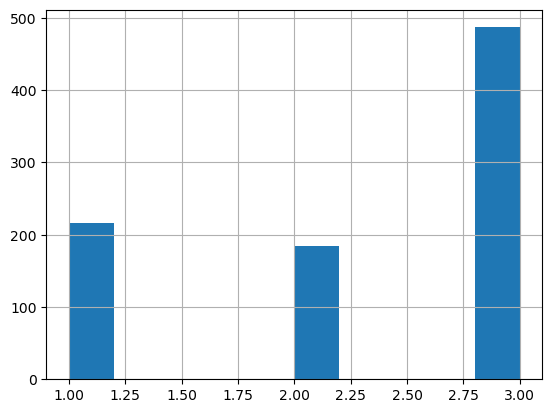

In [14]:
data['Pclass'].hist()

<Axes: >

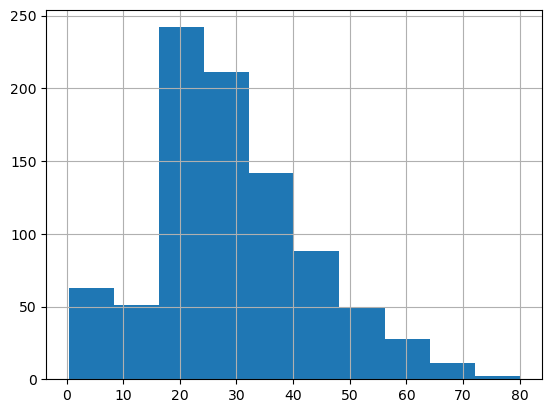

In [15]:
data['Age'].hist()

<Axes: >

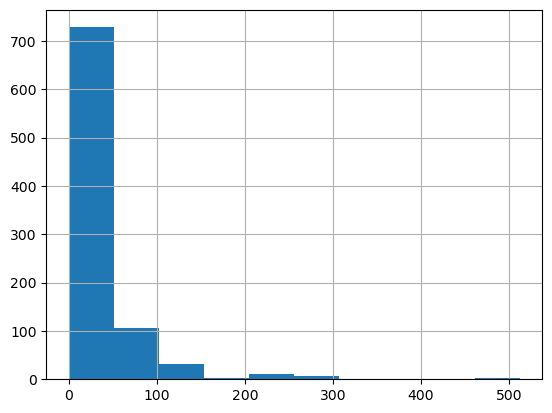

In [16]:
data['Fare'].hist()

## How to select data in Pandas?

In SQL we can select data from this database, let us call it Titanic, by doing:
```
SELECT *
FROM Titanic
```
This corresponds to calling the variable 
```
data
```

If we want to select only certain columns, in SQL we will do:

SELECT Pclass, Name
FROM Titanic

In pandas, we can call:

In [17]:
data[['Pclass', 'Name']]

,Pclass,Name
0,3,Mr. Owen Harris Braund
1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...
2,3,Miss. Laina Heikkinen
3,1,Mrs. Jacques Heath (Lily May Peel) Futrelle
4,3,Mr. William Henry Allen
...,...,...
882,2,Rev. Juozas Montvila
883,1,Miss. Margaret Edith Graham
884,3,Miss. Catherine Helen Johnston
885,1,Mr. Karl Howell Behr


In SQL we can change a column value, for example making a division, by doing:
```
SELECT "Siblings/Spouses Aboard", "Parents/Children Aboard","Parents/Children Aboard" + "Siblings/Spouses Aboard" as family
FROM Titanic
```
In Pandas we can not do this directly, we need to create a new column:

In [18]:
data['Family'] = data['Siblings/Spouses Aboard'] + data['Parents/Children Aboard']

In [19]:
data[['Siblings/Spouses Aboard', 'Parents/Children Aboard', 'Family']]

,Siblings/Spouses Aboard,Parents/Children Aboard,Family
0,1,0,1
1,1,0,1
2,0,0,0
3,1,0,1
4,0,0,0
...,...,...,...
882,0,0,0
883,0,0,0
884,1,2,3
885,0,0,0


The limit value can be given in two different ways:

```
data.head(n)

data[:n]
```

It is possible also, differently from SQL, to easily select the m to n value



In [20]:
data.head(10)

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,Family
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500,1
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833,1
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250,0
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000,1
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500,0
5,0,3,Mr. James Moran,male,27.0,0,0,8.4583,0
6,0,1,Mr. Timothy J McCarthy,male,54.0,0,0,51.8625,0
7,0,3,Master. Gosta Leonard Palsson,male,2.0,3,1,21.0750,4
8,1,3,Mrs. Oscar W (Elisabeth Vilhelmina Berg) Johnson,female,27.0,0,2,11.1333,2
9,1,2,Mrs. Nicholas (Adele Achem) Nasser,female,14.0,1,0,30.0708,1


In [21]:
data[:10]

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,Family
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500,1
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833,1
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250,0
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000,1
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500,0
5,0,3,Mr. James Moran,male,27.0,0,0,8.4583,0
6,0,1,Mr. Timothy J McCarthy,male,54.0,0,0,51.8625,0
7,0,3,Master. Gosta Leonard Palsson,male,2.0,3,1,21.0750,4
8,1,3,Mrs. Oscar W (Elisabeth Vilhelmina Berg) Johnson,female,27.0,0,2,11.1333,2
9,1,2,Mrs. Nicholas (Adele Achem) Nasser,female,14.0,1,0,30.0708,1


In [22]:
data[134:145]

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,Family
134,0,2,Mr. Emile Richard,male,23.0,0,0,15.0458,0
135,1,1,Miss. Helen Monypeny Newsom,female,19.0,0,2,26.2833,2
136,0,1,Mr. Jacques Heath Futrelle,male,37.0,1,0,53.1000,1
137,0,3,Mr. Olaf Elon Osen,male,16.0,0,0,9.2167,0
138,0,1,Mr. Victor Giglio,male,24.0,0,0,79.2000,0
139,0,3,Mrs. Joseph (Sultana) Boulos,female,40.0,0,2,15.2458,2
140,1,3,Miss. Anna Sofia Nysten,female,22.0,0,0,7.7500,0
141,1,3,Mrs. Pekka Pietari (Elin Matilda Dolck) Hakkar...,female,24.0,1,0,15.8500,1
142,0,3,Mr. Jeremiah Burke,male,19.0,0,0,6.7500,0
143,0,2,Mr. Edgardo Samuel Andrew,male,18.0,0,0,11.5000,0


## Exercise 3

Select columns Sex, Age and Fare. 

Select last 50 data points for the three columns


In [23]:
data[['Sex', 'Age', 'Fare']]

,Sex,Age,Fare
0,male,22.0,7.2500
1,female,38.0,71.2833
2,female,26.0,7.9250
3,female,35.0,53.1000
4,male,35.0,8.0500
...,...,...,...
882,male,27.0,13.0000
883,female,19.0,30.0000
884,female,7.0,23.4500
885,male,26.0,30.0000


In [24]:
data[['Sex', 'Age', 'Fare']].tail(50)

,Sex,Age,Fare
837,male,16.0,10.5000
838,female,30.0,31.0000
839,male,34.5,6.4375
840,male,17.0,8.6625
841,male,42.0,7.5500
842,male,18.0,69.5500
843,male,35.0,7.8958
844,male,28.0,33.0000
845,female,40.0,89.1042
846,male,4.0,31.2750


## The where clause

In SQL we can filter the data by using the WHERE clause. For example, to find all the survivor we can do:
```
SELECT * 
FROM Titanic
WHERE Survived=1
```

In Pandas, we can filter it by adding a condition
```
data[data['Survived'] == 1]
```

If we want to save the dataset for further analysis, we can assign it to a variable:
```
data_survived = data[data['Survived'] == 1]
```

In [25]:
data[data['Survived'] == 1]


,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,Family
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833,1
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250,0
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000,1
8,1,3,Mrs. Oscar W (Elisabeth Vilhelmina Berg) Johnson,female,27.0,0,2,11.1333,2
9,1,2,Mrs. Nicholas (Adele Achem) Nasser,female,14.0,1,0,30.0708,1
...,...,...,...,...,...,...,...,...,...
871,1,3,Miss. Adele Kiamie Najib,female,15.0,0,0,7.2250,0
875,1,1,Mrs. Thomas Jr (Lily Alexenia Wilson) Potter,female,56.0,0,1,83.1583,1
876,1,2,Mrs. William (Imanita Parrish Hall) Shelley,female,25.0,0,1,26.0000,1
883,1,1,Miss. Margaret Edith Graham,female,19.0,0,0,30.0000,0


In SQL we can use different conditions by using AND and OR:

```
SELECT *
FROM Titanic
WHERE Sex='female' AND Age > 30
```

In pandas the AND condition is not the same "and" as usual in Pyhon, but we use the bitwise comparison &

```
data[(data['Sex'] == 'female' ) & data['Age'] > 30)]

```



In [26]:
data[(data['Sex'] == 'female' ) & (data['Age'] > 30)]


,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,Family
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833,1
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000,1
11,1,1,Miss. Elizabeth Bonnell,female,58.0,0,0,26.5500,0
15,1,2,Mrs. (Mary D Kingcome) Hewlett,female,55.0,0,0,16.0000,0
18,0,3,Mrs. Julius (Emelia Maria Vandemoortele) Vande...,female,31.0,1,0,18.0000,1
...,...,...,...,...,...,...,...,...,...
858,1,1,Mrs. Frederick Joel (Margaret Welles Barron) S...,female,48.0,0,0,25.9292,0
861,1,2,Mrs. (Karolina) Bystrom,female,42.0,0,0,13.0000,0
867,1,1,Mrs. Richard Leonard (Sallie Monypeny) Beckwith,female,47.0,1,1,52.5542,2
875,1,1,Mrs. Thomas Jr (Lily Alexenia Wilson) Potter,female,56.0,0,1,83.1583,1


The same for OR:

```
SELECT *
FROM Titanic
WHERE Age> 65 or Age < 18
```

In Pandas the OR is translated with the bitwise operation |
```
data[(data['Age'] < 18) | (data['Age'] > 65)]
```


In [27]:
data[(data['Age'] < 18) | (data['Age'] > 65)]


,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,Family
7,0,3,Master. Gosta Leonard Palsson,male,2.0,3,1,21.0750,4
9,1,2,Mrs. Nicholas (Adele Achem) Nasser,female,14.0,1,0,30.0708,1
10,1,3,Miss. Marguerite Rut Sandstrom,female,4.0,1,1,16.7000,2
14,0,3,Miss. Hulda Amanda Adolfina Vestrom,female,14.0,0,0,7.8542,0
16,0,3,Master. Eugene Rice,male,2.0,4,1,29.1250,5
...,...,...,...,...,...,...,...,...,...
849,1,1,Miss. Mary Conover Lines,female,16.0,0,1,39.4000,1
859,0,3,Miss. Dorothy Edith Sage,female,14.0,8,2,69.5500,10
865,1,3,Master. Harold Theodor Johnson,male,4.0,1,1,11.1333,2
871,1,3,Miss. Adele Kiamie Najib,female,15.0,0,0,7.2250,0


To select only some columns, you can add the list of variable at the end of the command, as for the select command

In SQL

```
SELECT Age, Survived
FROM Titanic
WHERE Age> 65 or Age < 18
```

In Pandas:
```
data[(data['Age'] < 18) | (data['Age'] > 65)][['Age', 'Survived']]
```

In [28]:
data[(data['Age'] < 18) | (data['Age'] > 65)][['Age', 'Survived']]


,Age,Survived
7,2.0,0
9,14.0,1
10,4.0,1
14,14.0,0
16,2.0,0
...,...,...
849,16.0,1
859,14.0,0
865,4.0,1
871,15.0,1


In [29]:
data['Age'].unique()

array([22.  , 38.  , 26.  , 35.  , 27.  , 54.  ,  2.  , 14.  ,  4.  ,
       58.  , 20.  , 39.  , 55.  , 23.  , 31.  , 34.  , 15.  , 28.  ,
        8.  , 19.  , 24.  , 40.  , 48.  , 18.  , 66.  , 42.  , 21.  ,
        3.  , 30.  , 16.  ,  7.  , 49.  , 29.  , 65.  , 46.  , 28.5 ,
        5.  , 11.  , 45.  , 64.  , 17.  , 32.  , 25.  ,  0.83, 33.  ,
       59.  , 71.  , 37.  , 47.  , 14.5 , 70.5 , 32.5 , 12.  ,  9.  ,
       36.5 , 51.  , 55.5 , 40.5 , 44.  ,  1.  , 60.  , 61.  , 56.  ,
       50.  , 36.  , 45.5 , 20.5 , 62.  , 41.  , 52.  , 63.  , 57.  ,
       23.5 ,  0.92, 43.  , 10.  , 13.  ,  0.75, 69.  , 53.  , 80.  ,
       70.  , 24.5 ,  6.  ,  0.67, 30.5 ,  0.42, 34.5 , 74.  ])

Null checking is done with the methods notna() and isna()

In [30]:
data.isna()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,Family
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
882,False,False,False,False,False,False,False,False,False
883,False,False,False,False,False,False,False,False,False
884,False,False,False,False,False,False,False,False,False
885,False,False,False,False,False,False,False,False,False


If we want to see for columns, we can do:

In [31]:
data.isna().sum()

Survived                   0
Pclass                     0
Name                       0
Sex                        0
Age                        0
Siblings/Spouses Aboard    0
Parents/Children Aboard    0
Fare                       0
Family                     0
dtype: int64

There are no missing values for this dataframe.

**Exercice 4**

Select all rows where age is smaller than 25 and show the columns 'Age' and 'Survived'

Select all rows where sex if Female, age is smaller than 60. Plot a histogram for the Survived column for this selection.

Select all rows where sex if male, PClass is 3.  Plot a histogram for the Survived column for this selection.

Select all rows where sex if male, PClass is 1.  Plot a histogram for the Survived column for this selection.

Select all rows where sex if Female or Pclass is 1. Plot a histogram for the Survived column for this selection.


In [32]:
data[data['Age'] < 25][['Age', 'Survived']]

,Age,Survived
0,22.0,0
7,2.0,0
9,14.0,1
10,4.0,1
12,20.0,0
...,...,...
873,19.0,0
874,23.0,0
878,22.0,0
883,19.0,1


<Axes: >

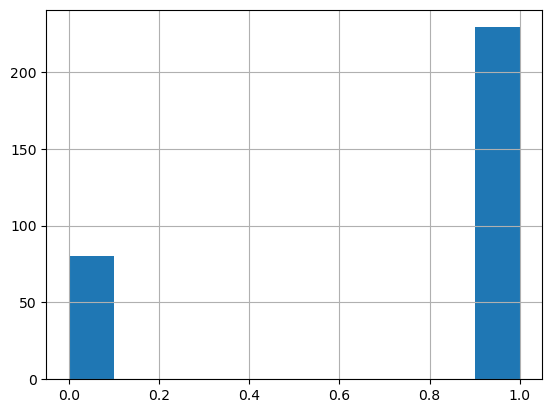

In [33]:
data[(data['Sex'] == 'female') & (data['Age'] < 60)]['Survived'].hist()

<Axes: >

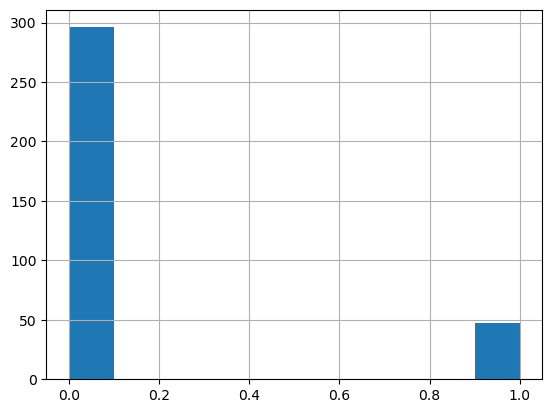

In [34]:
data[(data['Sex'] == 'male') & (data['Pclass'] == 3)]['Survived'].hist()

<Axes: >

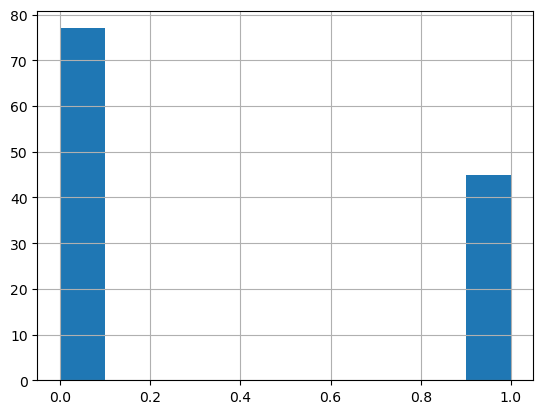

In [35]:
data[(data['Sex'] == 'male') & (data['Pclass'] == 1)]['Survived'].hist()

<Axes: >

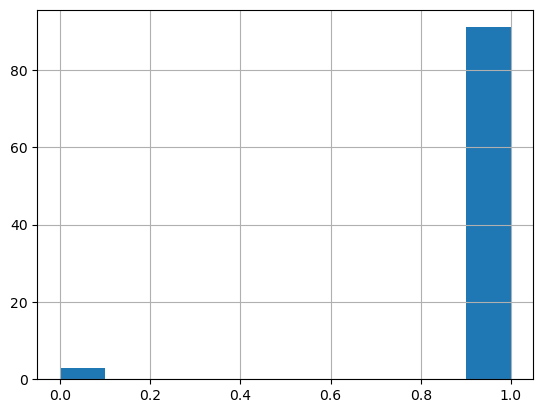

In [36]:
data[(data['Sex'] == 'female') & (data['Pclass'] == 1)]['Survived'].hist()

## The Group By Clause

In SQL it is possible to group by columns to understand the data. For example, let us consider that we want to understand how many people have survived with respect to the Sex. We can do:

```
SELECT Survived, Sex, COUNT(Sex), 
FROM Titanic
GROUP BY Survived, Sex
```

In pandas it becomes:


In [37]:
data.groupby(['Survived', 'Sex']).count()

Pclass  Name  Age  Siblings/Spouses Aboard  \
Survived Sex                                                  
0        female      81    81   81                       81   
         male       464   464  464                      464   
1        female     233   233  233                      233   
         male       109   109  109                      109   

                 Parents/Children Aboard  Fare  Family  
Survived Sex                                            
0        female                       81    81      81  
         male                        464   464     464  
1        female                      233   233     233  
         male                        109   109     109

if we look at the type, this is not a dataframe. This can be quite cumbersome in the future, so we can call the reset_index() property to return a proper dataframe

In [38]:
print(type(data.groupby(['Survived', 'Sex'])['Sex'].count()))

<class 'pandas.core.series.Series'>


In [39]:
print(type(data.groupby(['Survived', 'Sex']).count().reset_index()))

<class 'pandas.core.frame.DataFrame'>


In [40]:
data.groupby(['Survived', 'Sex']).count().reset_index()[['Survived', 'Sex', 'Age']].rename(columns={'Age': 'Count'})

,Survived,Sex,Count
0,0,female,81
1,0,male,464
2,1,female,233
3,1,male,109


We can have multiple values computed, for example we would like to do:

```
SELECT Survived, AVG(Age), STD(Age)
FROM Titanic
GROUP BY Survived
```

In pandas it becomes

In [41]:
data.groupby('Survived')['Age'].agg(["median", "mean", 'std']).reset_index()

,Survived,median,mean,std
0,0,28.0,30.138532,13.898317
1,1,28.0,28.408392,14.427863


In [42]:
data.groupby('Survived')['Fare'].agg(["median", "mean", 'std']).reset_index()

,Survived,median,mean,std
0,0,10.5,22.208584,31.484153
1,1,26.0,48.395408,66.596998


## Exercise 4

Compute the survival rate for both male and female.

Compute the mean and std for age group for passangers in 1, 2 and 3 class.

Compute the mean and std for age group for passangers in 1, 2 and 3 class, for both male and female.

Compute the mean and std for fare for passangers in 1, 2 and 3 class, for both male and female.



In [43]:
data.groupby('Sex')['Survived'].sum()/ data.groupby('Sex')['Sex'].count()


Sex
female    0.742038
male      0.190227
dtype: float64

In [44]:
data.groupby('Pclass')['Age'].agg(['mean', 'std'])

,mean,std
Pclass,,
1,38.788981,14.183633
2,29.868641,13.756191
3,25.188747,12.095084


In [45]:
data.groupby(['Pclass', 'Sex'])['Age'].agg(['mean', 'std'])

mean        std
Pclass Sex                         
1      female  35.255319  13.257529
       male    41.511639  14.324665
2      female  28.980263  12.855723
       male    30.493796  14.382035
3      female  22.135417  12.181031
       male    26.470612  11.843691

In [46]:
data.groupby(['Pclass', 'Sex'])['Fare'].agg(['mean', 'std'])

mean        std
Pclass Sex                          
1      female  106.125798  74.259988
       male     67.226127  77.548021
2      female   21.970121  10.891796
       male     19.741782  14.922235
3      female   16.118810  11.690314
       male     12.695466  11.740102

## Order By

In SQL we can easily order the database by using a column.

```
SELECT Age, Sex
FROM Titanic
ORDER BY Age DESC
```

In Pandas it becomes:

```
data.sort_values('Age')[['Age', 'Sex']]
```

In [47]:
data.sort_values('Age')[['Age', 'Sex']]

,Age,Sex
799,0.42,male
751,0.67,male
641,0.75,female
466,0.75,female
827,0.83,male
...,...,...
115,70.50,male
490,71.00,male
95,71.00,male
847,74.00,male


In [48]:
data.sort_values('Age', ascending=False)[['Age', 'Sex']]

,Age,Sex
627,80.00,male
847,74.00,male
490,71.00,male
95,71.00,male
115,70.50,male
...,...,...
77,0.83,male
466,0.75,female
641,0.75,female
751,0.67,male


## Exercise 5

Select all male passangers who survived and order them by age (descending).

Select all male passangers who survived and in first class and order them by age (descending).

Select all male passangers who survived and in third class and order them by age (descending).

Order all passangers by fare (ascending). What can you notice about the PClass?



In [49]:
data[(data['Sex'] == 'male') & (data['Survived'] == 1)].sort_values('Age', ascending=False)

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,Family
627,1,1,Mr. Algernon Henry Wilson Barkworth,male,80.00,0,0,30.0000,0
567,1,2,Mr. George Harris,male,62.00,0,0,10.5000,0
584,1,1,Mr. Maxmillian Frolicher-Stehli,male,60.00,1,1,79.2000,2
644,1,1,Col. Oberst Alfons Simonius-Blumer,male,56.00,0,0,35.5000,0
446,1,1,Major. Arthur Godfrey Peuchen,male,52.00,0,0,30.5000,0
...,...,...,...,...,...,...,...,...,...
303,1,1,Master. Hudson Trevor Allison,male,0.92,1,2,151.5500,3
827,1,2,Master. George Sibley Richards,male,0.83,1,1,18.7500,2
77,1,2,Master. Alden Gates Caldwell,male,0.83,0,2,29.0000,2
751,1,2,Master. Viljo Hamalainen,male,0.67,1,1,14.5000,2


In [50]:
data[(data['Sex'] == 'male') & (data['Survived'] == 1) & (data['Pclass'] == 1)].sort_values('Age', ascending=False)

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,Family
627,1,1,Mr. Algernon Henry Wilson Barkworth,male,80.00,0,0,30.0000,0
584,1,1,Mr. Maxmillian Frolicher-Stehli,male,60.00,1,1,79.2000,2
644,1,1,Col. Oberst Alfons Simonius-Blumer,male,56.00,0,0,35.5000,0
446,1,1,Major. Arthur Godfrey Peuchen,male,52.00,0,0,30.5000,0
853,1,1,Mr. Peter Denis Daly,male,51.00,0,0,26.5500,0
657,1,1,Dr. Henry William Frauenthal,male,50.00,2,0,133.6500,2
450,1,1,Mr. Samuel L Goldenberg,male,49.00,1,0,89.1042,1
596,1,1,Sir. Cosmo Edmund Duff Gordon,male,49.00,1,0,56.9292,1
457,1,1,Mr. Harry Anderson,male,48.00,0,0,26.5500,0
642,1,1,Mr. Henry Sleeper Harper,male,48.00,1,0,76.7292,1


In [51]:
data[(data['Sex'] == 'male') & (data['Survived'] == 1) & (data['Pclass'] == 3)].sort_values('Age', ascending=False)

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,Family
336,1,3,Mr. Karl Edwart Dahl,male,45.00,0,0,8.0500,0
412,1,3,Mr. Johan Julian Sundman,male,44.00,0,0,7.9250,0
398,1,3,Mr. Juha Niskanen,male,39.00,0,0,7.9250,0
689,1,3,Mr. Ali Lam,male,37.00,0,0,56.4958,0
426,1,3,Mr. Berk (Berk Trembisky) Pickard,male,32.00,0,0,8.0500,0
640,1,3,Mr. Choong Foo,male,32.00,0,0,56.4958,0
73,1,3,Mr. Lee Bing,male,32.00,0,0,56.4958,0
576,1,3,Mr. Eiriik Jussila,male,32.00,0,0,7.9250,0
566,1,3,Mr. Carl Jonsson,male,32.00,0,0,7.8542,0
834,1,3,Mr. Chang Chip,male,32.00,0,0,56.4958,0


## Same basic data cleanings

### Change values in a column by using apply

In [52]:
def set_gender(x):
    if x == 'male':
        return 1
    else:
        return 0

data['Sex'] = data['Sex'].apply(lambda x: 1 if x=='male' else 0)

We can use apply for example to extract the titles from the names

In [53]:
data['title'] = data['Name'].apply(lambda x: x.split('.')[0])

In [54]:
data['title'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Don', 'Rev', 'Dr', 'Mme', 'Ms',
       'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'the Countess',
       'Jonkheer'], dtype=object)

In [55]:
data.groupby(['title'])['Name'].count().reset_index().rename({'Name': 'Count'}, axis=1).sort_values('Count', ascending=False)

,title,Count
11,Mr,513
8,Miss,182
12,Mrs,125
7,Master,40
3,Dr,7
14,Rev,6
6,Major,2
1,Col,2
9,Mlle,2
15,Sir,1


In [60]:
for title in data['title'].unique():
    data_title = data[data['title'] == title]
    print(f'{title} survived percentage: {len(data_title[data_title["Survived"] == 1])/len(data_title)}')

Mr survived percentage: 0.15789473684210525
Mrs survived percentage: 0.792
Miss survived percentage: 0.6978021978021978
Master survived percentage: 0.575
Don survived percentage: 0.0
Rev survived percentage: 0.0
Dr survived percentage: 0.42857142857142855
Mme survived percentage: 1.0
Ms survived percentage: 1.0
Major survived percentage: 0.5
Lady survived percentage: 1.0
Sir survived percentage: 1.0
Mlle survived percentage: 1.0
Col survived percentage: 0.5
Capt survived percentage: 0.0
the Countess survived percentage: 1.0
Jonkheer survived percentage: 0.0


## Exercise 6

Create a new column Age_Group with following age bands:
- < 18
- 18-25
- 26-45
- 46-60
- 61+

Create a new column Fare_Group with following fare bands:
- < 20
- 20-50
- 50-100
- 100-200
- 200+

Map the titles to either:
- Mister
- Madame
- Miss
- Other

How did you choose this mapping? Compute the survival rate for each title. How does it compare to the survival rate with respect to the variable Sex?

<Axes: >

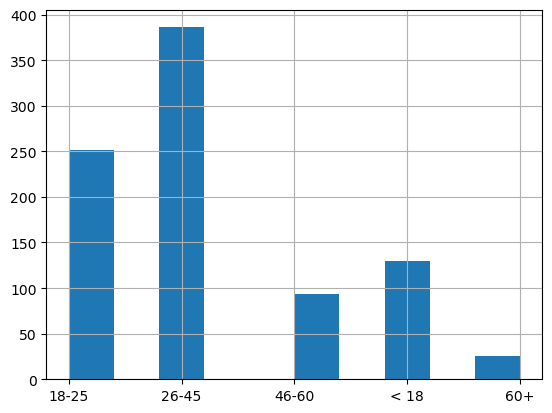

In [61]:
def map_age(x):
    if x < 18:
        return '< 18'
    if x <= 25:
        return '18-25'
    if x <= 45:
        return '26-45'
    if x <= 60:
        return '46-60'
    return '60+'

data['Age_Group'] = data['Age'].apply(lambda x: map_age(x))
data['Age_Group'].hist()

In [62]:
def fare_group(x):
    if x < 20:
        return '<20'
    if x < 50:
        return '20-50'
    if x < 100:
        return '50-100'
    if x < 200:
        return '100-200'
    return '200+'

data['Fare_Group'] = data['Fare'].apply(lambda x: fare_group(x))

<Axes: >

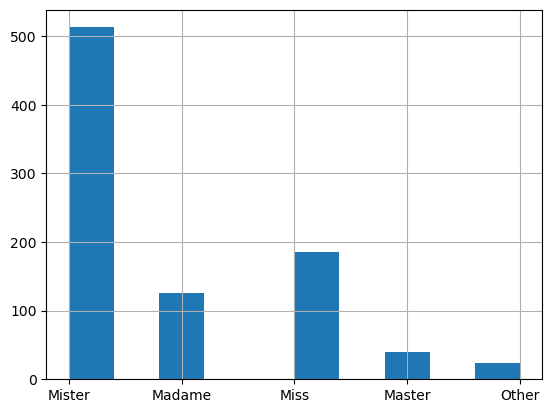

In [63]:
def map_title(title):
    title_mapping = {
        'Mister': 'Mister',
        'Madame': 'Madame',
        'Mr': 'Mister', 
        'Mrs': 'Madame', 
        'Miss': 'Miss', 
        'Master': 'Master', 
        'Don': 'Other', 
        'Rev': 'Other', 
        'Dr': 'Other', 
        'Mme': 'Madame', 
        'Ms': 'Miss',
        'Major': 'Other', 
        'Lady': 'Other', 
        'Sir': 'Other', 
        'Mlle': 'Miss', 
        'Col': 'Other', 
        'Capt': 'Other', 
        'the Countess': 'Other',
        'Jonkheer': 'Other'
    }
    return title_mapping[title]
    
data['map_title'] = data['title'].apply(lambda x: map_title(x))
data['map_title'].hist()

In [64]:
data.groupby('map_title')['Survived'].sum()/data.groupby('map_title')['Survived'].count()

map_title
Madame    0.793651
Master    0.575000
Miss      0.702703
Mister    0.157895
Other     0.347826
Name: Survived, dtype: float64

In [65]:
data.groupby(['Sex', 'map_title'])['Age'].count()

Sex  map_title
0    Madame       126
     Miss         185
     Other          3
1    Master        40
     Mister       513
     Other         20
Name: Age, dtype: int64

In [66]:
data.groupby('Sex')['Survived'].sum()/data.groupby('Sex')['Survived'].count()

Sex
0    0.742038
1    0.190227
Name: Survived, dtype: float64

## Merging tables

In [67]:
df1 = pd.DataFrame({"A": [1,2,3, 4], "B": [2,3,4, 4]})
df2 = pd.DataFrame({"A": [1, 3 ,3, 5], "C": [2, 2, 5, 1]})

In [68]:
df1

,A,B
0,1,2
1,2,3
2,3,4
3,4,4


In [69]:
df2

,A,C
0,1,2
1,3,2
2,3,5
3,5,1


In [70]:
print('INNER JOIN')

df1.merge(df2, on="A")

INNER JOIN


,A,B,C
0,1,2,2
1,3,4,2
2,3,4,5


We return all indexes that are in both DataFrame

In [71]:
print('LEFT JOIN')

df1.merge(df2, how='left', on="A")

LEFT JOIN


,A,B,C
0,1,2,2.0
1,2,3,NaN
2,3,4,2.0
3,3,4,5.0
4,4,4,NaN


We return all indexes that are in the first dataframe (the left one). If data is missing from the second dataframe, we return NotANumber

In [72]:
print('RIGHT JOIN')

df1.merge(df2, how='right', on="A")

RIGHT JOIN


,A,B,C
0,1,2.0,2
1,3,4.0,2
2,3,4.0,5
3,5,NaN,1


We return all indexes that are in the second dataframe (the right one). If data is missing from the first dataframe, we return NotANumber

In [73]:
print('OUTER JOIN')


df1.merge(df2, how='outer', on="A")

OUTER JOIN


,A,B,C
0,1,2.0,2.0
1,2,3.0,NaN
2,3,4.0,2.0
3,3,4.0,5.0
4,4,4.0,NaN
5,5,NaN,1.0


We return all indexes that are in both dataframes. If data is missing, we return NotANumber

